In [1]:
import os
import sys
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import matplotlib.pyplot as plt
import re
import anndata as ad
import statistics
import tempfile
import cosg
import celltypist
sc._settings.ScanpyConfig.n_jobs=24
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png')
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 100)
import warnings
warnings.filterwarnings('ignore')

In [2]:
sc.logging.print_header()

Package,Version
scipy,1.15.2
numpy,2.2.5
pandas,2.2.3
scanpy,1.11.1
seaborn,0.13.2
matplotlib,3.9.2
anndata,0.11.4
cosg,1.0.1
celltypist,1.6.3
Component,Info


In [49]:
marker_dict2={
    'B': ['MS4A1','CD79A','BANK1','CD22','FCRL1','TCL1A','FCER2'],
    'Plasma|Plasmablast':['TNFRSF17','JCHAIN','IGHA1','MZB1','XBP1'],
    
    'CD4+ T':['TCF7','MAL','IL7R','RCAN3','DGKA',],
    'CD8+ T':['CD8A','CD8B','LINC02446','CCL5','THEMIS','KLRK1'],
    'MAIT':['SLC4A10','TRAV1-2','KLRB1',],
    'Platelet':['TUBB1','CAVIN2','PF4',],
    'NKT':['TRAV24','TRBV28','CLDND1','DZIP3','ORM2','GPRC5D','FGFR2'],
    'NK': ['KLRF1', 'SPON2','GNLY', 'GZMB','PRF1','KLRD1','TYROBP'],
    'non-NK ILC': ['FSTL4', 'HPGDS','PKIB', 'PTGDR2','SCART1'],
    'γδ T':['TRDC','TRDV2','TRGC1','TRGC2','TRGV9','KLRD1','CCL5','KLRC1'],
    
    'HPSC':['CD34','NPR3','SMIM24','SPINK2','CRHBP','EMP1','ACY3','NYNRIN'], 
    'DC':['ENHO','CLEC10A','CD1C','FCER1A','FLT3','HLA-DQA1'],
    'Classical monocyte':['FCN1','VCAN','LRP1','CD14','MS4A6A','CST3'],
    'Non-classical monocyte':['CDKN1C','CSF1R','CKB','NEURL1','LYPD2','AIF1'],
    'CEACAM8+ Neutrophil':['CEACAM8','LCN2','BPI','LTF','CRISP3','CEACAM6'],
    'CEACAM8- Neutrophil':['CSF3R','NAMPT','FCGR3B','IFITM2','SLC25A37','FCGR3B', 'S100A9'],
    'Eosinophil':['EPX', 'SIGLEC8', 'IL5RA'],
    'Basophil':['HDC','GATA2','MS4A2','AKAP12','CLC','IL4','RHOXF1P1',], 
    'Mast':['STXBP6', 'PPIL6', 'KIT',],
    'pDC':['SERPINF1','PTPRS','LILRA4','TNFRSF21','PLD4','SCT'],
    
    'Proliferative signal':['MKI67','TOP2A','STMN1'],
}

In [4]:
def check_dict_duplicates(dict):
    seen = set()
    dup = any(item in seen or seen.add(item) for lst in dict.values() for item in lst)
    if dup==False:
        return '无重复'
    else:
        return '有重复'

In [5]:
obj_path = '/home/liyanguo/MyImmuCell/04_MyImmuCell_TOTALVI/'
sc.settings.figdir = obj_path

In [6]:
dataset = "high_nCount_RNA"

# 1. Load data after cluster (raw count)

In [7]:
print(dataset)

high_nCount_RNA


In [8]:
adata = sc.read_h5ad(f'{obj_path}scRNA_MyImmuCell_{dataset}_HVG.h5ad',backed='r')

# 2. Set leiden group and identify cell identity

In [9]:
groupby = "L1_leiden_TOTALVI_3"

In [10]:
adata.obs[groupby].value_counts()

L1_leiden_TOTALVI_3
26    1936645
3     1563578
14    1380902
36    1280621
29    1194664
39     994108
20     985981
33     954310
32     948228
24     871462
13     870923
44     866900
12     835904
15     825336
28     818870
17     816793
42     802748
23     801487
47     778904
9      714746
21     667282
34     660358
43     657757
4      635050
11     633312
38     593045
6      584514
48     514250
31     489535
27     445907
0      433303
22     384084
1      349920
8      348650
25     297313
35     246557
30     235428
40     223307
37     216872
2      213742
19     201484
16     192984
18     164309
46     123598
41     121538
5       79245
7       70887
49      61712
10      57207
45      30257
50      27930
52         10
51          5
Name: count, dtype: int64

In [11]:
adata

AnnData object with n_obs × n_vars = 30204462 × 2000 backed at '/home/liyanguo/MyImmuCell/04_MyImmuCell_TOTALVI/scRNA_MyImmuCell_high_nCount_RNA_HVG.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'High_quality', 'L1_leiden_TOTALVI_2', 'L1_leiden_TOTALVI_3', 'L1_leiden_TOTALVI_4', 'L1_leiden_TOTALVI_5'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'L1_leiden_TOTAL

In [12]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 10000,
                                                 by = groupby,
                                                 return_index = True,random_state=0)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

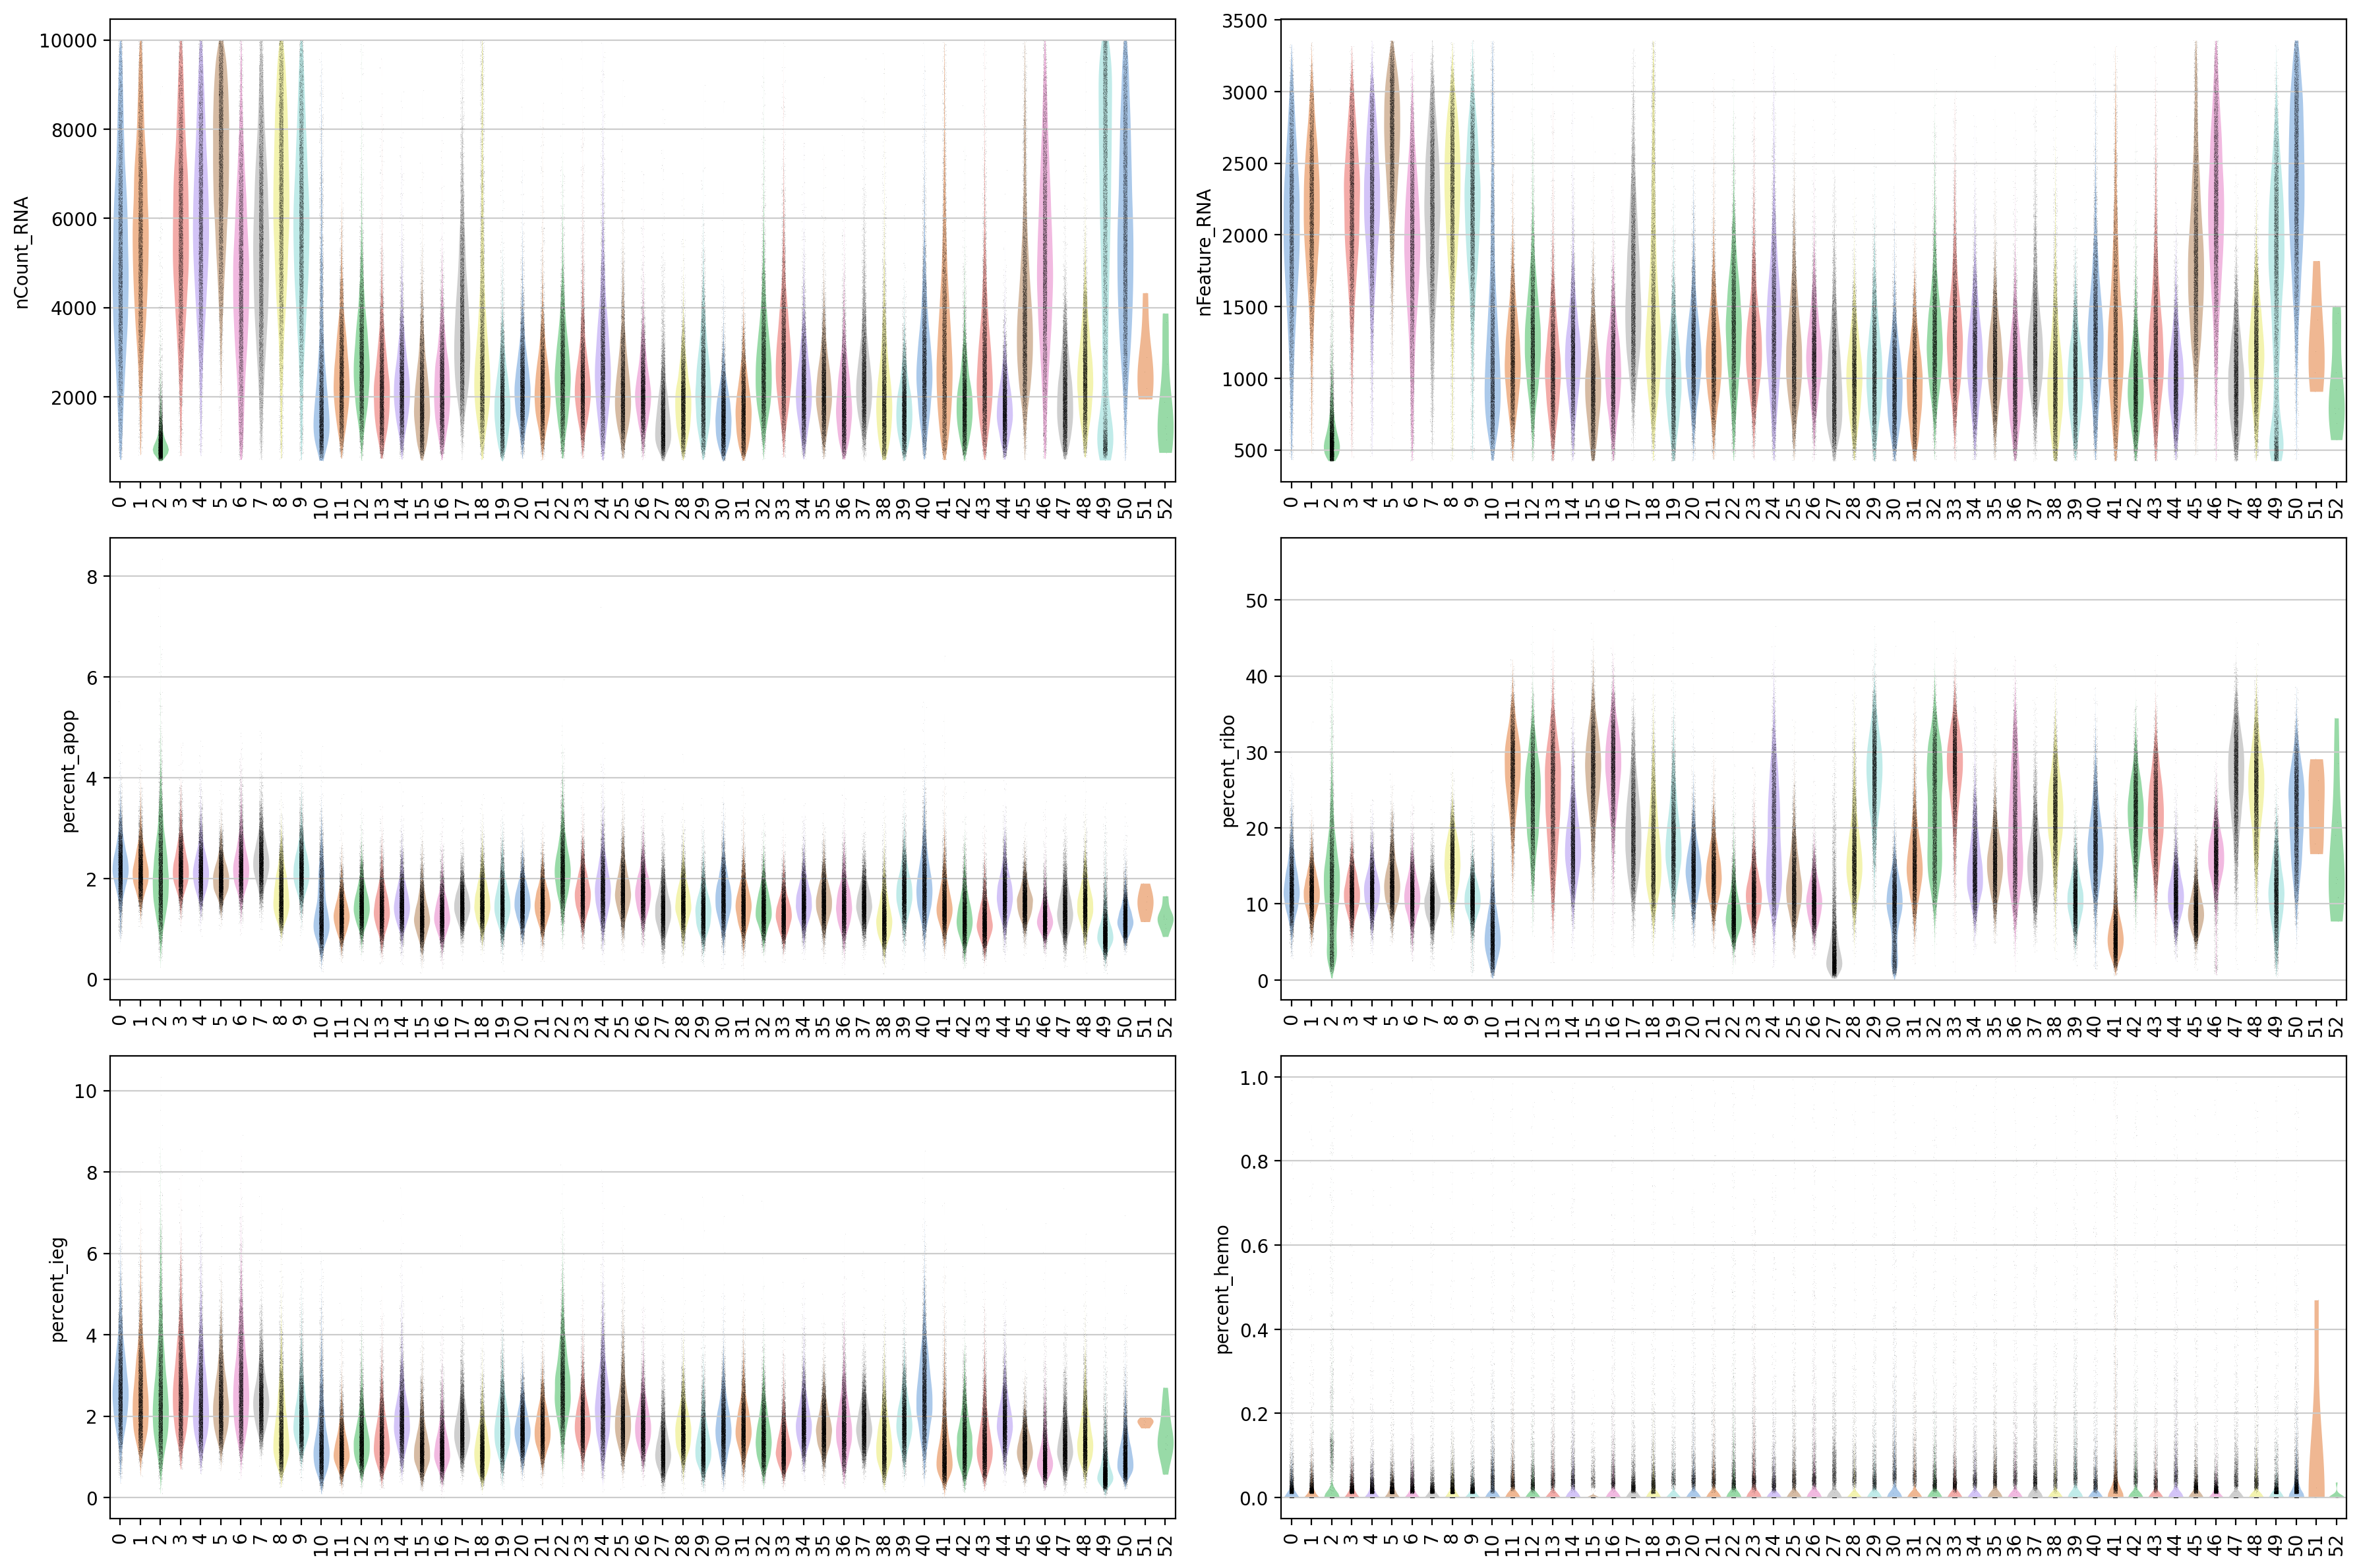

In [13]:
#数据簇间信息比较
fig, axs = plt.subplots(3, 2, figsize=(18, 12),constrained_layout=True)
sc.pl.violin(adata[cell_index], keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata[cell_index], keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{dataset}_{groupby}_TOTALVI_L1_metadata')

## 2.1 Clinical and Celltypist and Azimuth

In [14]:
xlsx = pd.ExcelWriter(f"{obj_path}{dataset}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class','Phase',
              'Reference_Atlas_L1L2_pl','Reference_Atlas_L1L2_mv',
              'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l1', 'predicted.celltype.l2']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

## 2.2 TCR BCR based annotation

In [15]:
#根据TCR识别部分细胞；TCR作为充分非必要条件
data_tcr = pd.read_csv("/home/liyanguo/MyImmuCell/02_Read_QC/scTCR_MyImmuCell.csv",index_col=0,usecols=[0,1,5,6])
data_bcr = pd.read_csv("/home/liyanguo/MyImmuCell/02_Read_QC/scBCR_MyImmuCell.csv",index_col=0,usecols=[0,1,5,6])

In [16]:
adata.obs = adata.obs.join(data_tcr, how='left')#TCR

In [17]:
adata.obs = adata.obs.join(data_bcr, how='left',rsuffix='_BCR')#BCR

In [18]:
adata.strings_to_categoricals()

... storing 'receptor_type' as categorical
... storing 'VJ_1_v_call' as categorical
... storing 'VJ_1_j_call' as categorical
... storing 'receptor_type_BCR' as categorical
... storing 'VJ_1_v_call_BCR' as categorical
... storing 'VJ_1_j_call_BCR' as categorical


In [19]:
adata.obs.receptor_type.value_counts()

receptor_type
TCR    13099361
Name: count, dtype: int64

In [20]:
adata.obs.receptor_type_BCR.value_counts()

receptor_type_BCR
BCR    2562519
Name: count, dtype: int64

In [21]:
xlsx = pd.ExcelWriter(f"{obj_path}{dataset}_freq_table_tcrbcr.xlsx")
for group in ['receptor_type', 
              'receptor_type_BCR',]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    freq_table_multi.to_excel(xlsx,sheet_name=group)
xlsx.close()

## 2.3 Source of Doublet

In [22]:
data = adata.obs.loc[:,[groupby,'scDblFinder.class','receptor_type','receptor_type_BCR',
                        'Reference_Atlas_L1L2_mv','Immune_All_High',
                        'AIFI_L1','predicted.celltype.l1']]

In [23]:
xlsx = pd.ExcelWriter(f"{obj_path}{dataset}_scDblFinder_freq_table.xlsx")
for i in ["5",'17','24']:
    tmp = data[data[groupby].isin([i])]
    for group in ['Reference_Atlas_L1L2_mv','receptor_type','receptor_type_BCR',
                  'Immune_All_High',
                  'AIFI_L1','predicted.celltype.l1']:
        freq_table_multi = tmp.groupby(['scDblFinder.class', group]).size()
        pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=f"{i}_{group}")
    del tmp
xlsx.close()

# 3. Cell_dict: fill in the clusters that belong to each cell type

In [78]:
cell_dict = {'Low quality':['2',#low nCount
                            
                   ],
             
             'Doublet':['5',#Monocyte和T混合，scDblFinder
                        '51',
                        '52',
                       ],

             'B|Plasma':['10',#B和Mono混合
                  '38',
                  '40',#Neu污染
                  '42',
                  '43',
                  '49',
                 ],
             
             'pDC':['46'],#

             'Classical monocyte':['0',#有污染，nCount略有异常
                                   '1',#Neu和Myeloid混合
                                   '3',#Neu和Myeloid混合
                                   '4',
                                   '6'
                                  ],
             
             'Non-classical monocyte':['7',#Neu污染
                                       '9',#Neu和Monocyte混合，scDblFinder提示71%双细胞,
                                      ],
             
             'DC':['8',],
             
             'HSPC':['50'],#
             
             'CEACAM8+ Neutrophil':['41'],

             'CD56bright NK':['25',],
             
             'CD56dim NK':['22',#Neu污染
                            '23','26',
                            '30','39', '44',
                            '45',#MKI67
                  ],

             'γδ T':['34'],#scDblFinder提示20%双细胞
             'MAIT':[],
             
             'CD4+ T': ['11',#CD8混合
                        '12',
                        '13',#CD8混合
                        '15',#CD8混合
                        '16',#CD8混合
                        '18',#Treg
                        '19',
                        '29',
                        '33',#CD8混合
                        '35',
                        '47',
                        '48',
                        '27'#最有疑问的，T淋巴都是有CD7的。但这类缺乏CD7 CD3D CD4基因表达，表达CD247、ETV6、ANK3、BACH2等基因。表达CD3\CD4蛋白。
                       ],
             
             'TRAV1-2- CD8+ T':['14',
                       '17',#CD4混合
                       '20',#CD4CD8混合
                       '21',#
                       '24',#Neu污染
                       '28',#CD4混合
                       '31',
                       '32',#CD4混合
                       '36',#CD4混合
                       '37',
                       ],
            }

In [79]:
cell_dict.values()

dict_values([['2'], ['5', '51', '52'], ['10', '38', '40', '42', '43', '49'], ['46'], ['0', '1', '3', '4', '6'], ['7', '9'], ['8'], ['50'], ['41'], ['25'], ['22', '23', '26', '30', '39', '44', '45'], ['34'], [], ['11', '12', '13', '15', '16', '18', '19', '29', '33', '35', '47', '48', '27'], ['14', '17', '20', '21', '24', '28', '31', '32', '36', '37']])

In [80]:
check_dict_duplicates(cell_dict)

'无重复'

In [81]:
#del adata.obs['Celltype_L1_L2']

In [82]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2'] = i

In [83]:
#MAIT; TRAV1-2; The MAIT cell is dominated by cells that express a semi-invariant αβ TCR: Vα7.2–Jα33 in humans that is paired with a Vβ2 or Vβ13 chain
#https://www.nature.com/articles/ncomms4866
#https://www.nature.com/articles/s41590-023-01575-1#Abs1
adata.obs.loc[(adata.obs['VJ_1_v_call']=='TRAV1-2') & ((adata.obs['VJ_1_j_call']=='TRAJ33') | (adata.obs['VJ_1_j_call']=='TRAJ12') | (adata.obs['VJ_1_j_call']=='TRAJ20')),'Celltype_L1_L2']="MAIT"

In [84]:
#iNKT: Vα24-Jα18/Vβ11 chains in humans
adata.obs.loc[(adata.obs['VJ_1_v_call']=='TRAV24') & (adata.obs['VJ_1_j_call']=='TRAJ18'),'Celltype_L1_L2']="iNKT"

In [85]:
(adata.obs['Celltype_L1_L2'].isna()).value_counts()

Celltype_L1_L2
False    30204462
Name: count, dtype: int64

In [86]:
adata.strings_to_categoricals()

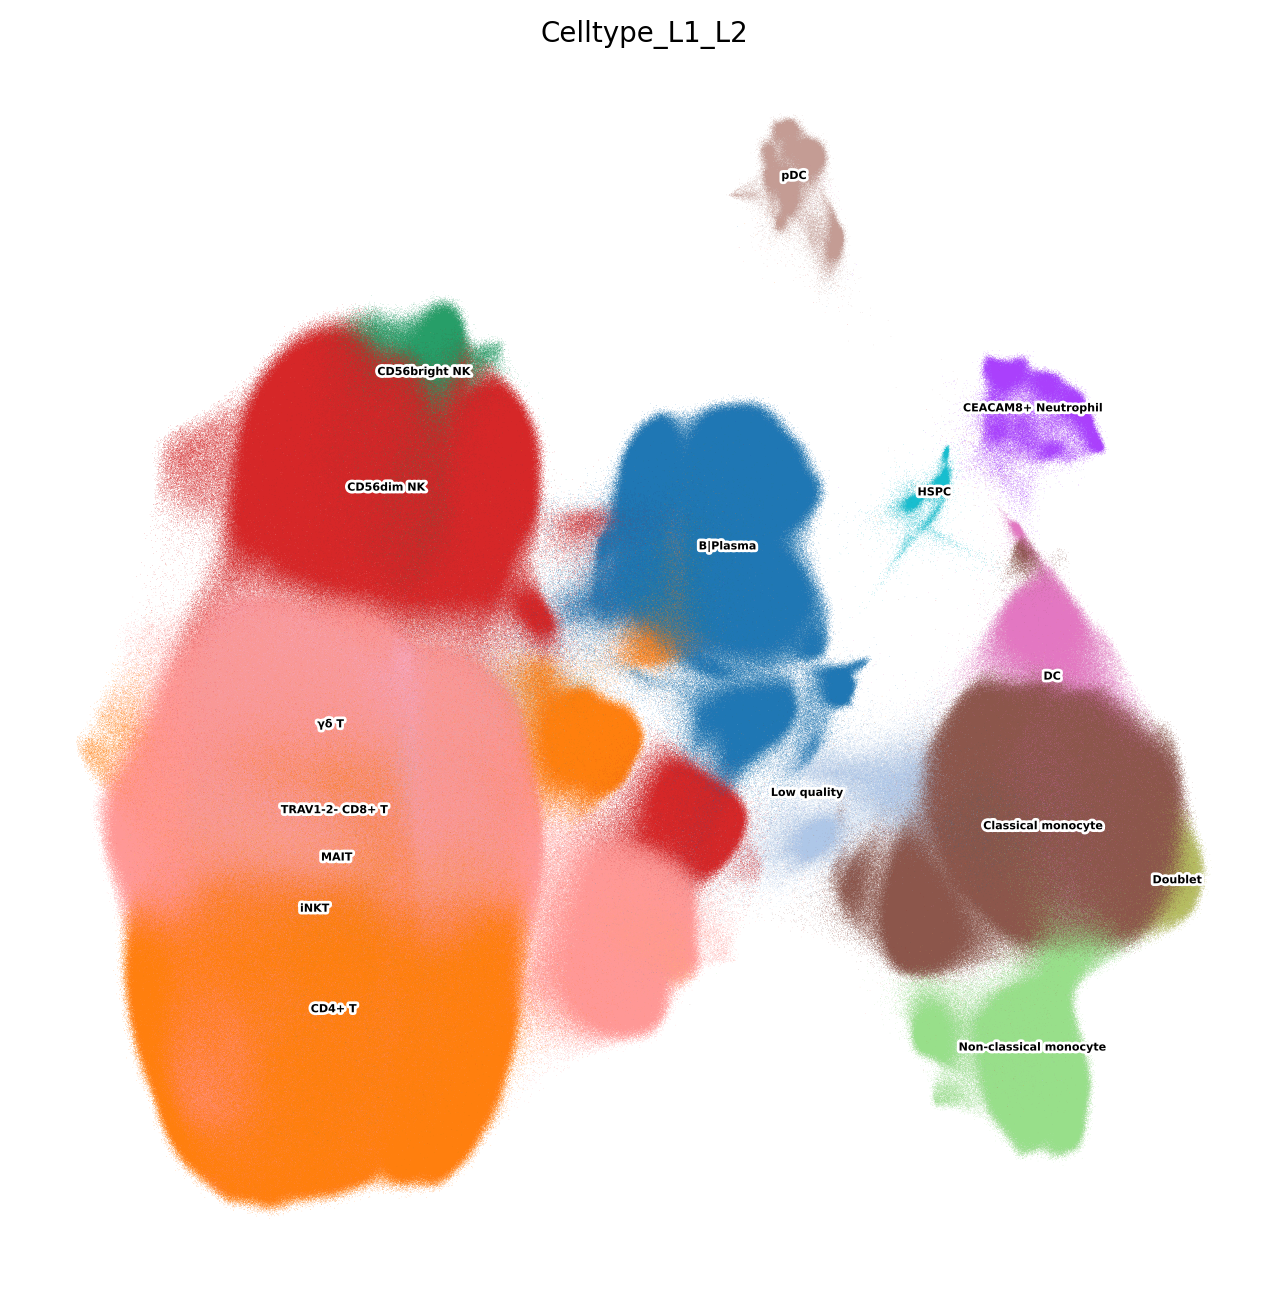

In [87]:
sc.pl.umap(adata, color=['Celltype_L1_L2'],
           save=f'_{dataset}_Celltype_L1_L2',
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=0.1,
           legend_loc='on data')

# 4. Level1 and Level2 Refine, Round1.

In [89]:
adata.obs.Celltype_L1_L2.value_counts()

Celltype_L1_L2
TRAV1-2- CD8+ T           8277920
CD4+ T                    7829391
CD56dim NK                5246890
Classical monocyte        3564185
B|Plasma                  2394787
Non-classical monocyte     785026
γδ T                       658444
DC                         348407
CD56bright NK              297220
MAIT                       236789
Low quality                213417
pDC                        123474
CEACAM8+ Neutrophil        121412
Doublet                     78161
HSPC                        27899
iNKT                         1040
Name: count, dtype: int64

In [90]:
CD8T=adata[adata.obs['Celltype_L1_L2'].isin(['TRAV1-2- CD8+ T']), :]
CD8T.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
TRAV1-2- CD8+ T    8277920
Name: count, dtype: int64

In [91]:
CD4T=adata[adata.obs['Celltype_L1_L2'].isin(['CD4+ T']), :]
CD4T.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
CD4+ T    7829391
Name: count, dtype: int64

In [92]:
CD56brightNK=adata[adata.obs['Celltype_L1_L2'].isin(['CD56bright NK']), :]
CD56brightNK.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
CD56bright NK    297220
Name: count, dtype: int64

In [93]:
CD56dimNK=adata[adata.obs['Celltype_L1_L2'].isin(['CD56dim NK']), :]
CD56dimNK.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
CD56dim NK    5246890
Name: count, dtype: int64

In [94]:
MAIT=adata[adata.obs['Celltype_L1_L2'].isin(['MAIT']), :]
MAIT.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
MAIT    236789
Name: count, dtype: int64

In [95]:
iNKT=adata[adata.obs['Celltype_L1_L2'].isin(['iNKT']), :]
iNKT.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
iNKT    1040
Name: count, dtype: int64

In [96]:
gdT=adata[adata.obs['Celltype_L1_L2'].isin(['γδ T']), :]
gdT.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
γδ T    658444
Name: count, dtype: int64

In [97]:
Classical_Monocyte=adata[adata.obs['Celltype_L1_L2'].isin(['Classical monocyte']), :]
Classical_Monocyte.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
Classical monocyte    3564185
Name: count, dtype: int64

In [98]:
Non_classical_Monocyte=adata[adata.obs['Celltype_L1_L2'].isin(['Non-classical monocyte']), :]
Non_classical_Monocyte.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
Non-classical monocyte    785026
Name: count, dtype: int64

In [99]:
CEACAM8_Pos_Neutrophil=adata[adata.obs['Celltype_L1_L2'].isin(['CEACAM8+ Neutrophil']), :]
CEACAM8_Pos_Neutrophil.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
CEACAM8+ Neutrophil    121412
Name: count, dtype: int64

In [100]:
DC=adata[adata.obs['Celltype_L1_L2'].isin(['DC']), :]
DC.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
DC    348407
Name: count, dtype: int64

In [101]:
B=adata[adata.obs['Celltype_L1_L2'].isin(['B|Plasma']), :]
B.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
B|Plasma    2394787
Name: count, dtype: int64

In [102]:
pDC=adata[adata.obs['Celltype_L1_L2'].isin(['pDC']), :]
pDC.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
pDC    123474
Name: count, dtype: int64

In [103]:
HSPC=adata[adata.obs['Celltype_L1_L2'].isin(['HSPC']), :]
HSPC.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
HSPC    27899
Name: count, dtype: int64

In [106]:
L2_refine_path='/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/'

In [107]:
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/Classical_Monocyte', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/Non_classical_Monocyte', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/CEACAM8_Pos_Neutrophil', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/CD56brightNK', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/CD56dimNK', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/CD8T', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/CD4T', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/MAIT', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/gdT', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/iNKT', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/B', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/DC', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/pDC', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/HSPC', exist_ok=True)

## Save cell index

In [108]:
indices_CEACAM8_Pos_Neutrophil = CEACAM8_Pos_Neutrophil.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_Classical_Monocyte = Classical_Monocyte.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_Non_classical_Monocyte = Non_classical_Monocyte.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_CD56brightNK = CD56brightNK.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_CD56dimNK = CD56dimNK.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_CD8T = CD8T.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_CD4T = CD4T.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_MAIT = MAIT.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_gdT = gdT.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_iNKT = iNKT.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_B = B.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_DC = DC.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_pDC = pDC.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_HSPC = HSPC.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]

In [110]:
indices_CEACAM8_Pos_Neutrophil.to_csv(f"{L2_refine_path}/Level2_Refine_R1/CEACAM8_Pos_Neutrophil/R1_indices_CEACAM8_Pos_Neutrophil.csv")
indices_Classical_Monocyte.to_csv(f"{L2_refine_path}/Level2_Refine_R1/Classical_Monocyte/R1_indices_Classical_Monocyte.csv")
indices_Non_classical_Monocyte.to_csv(f"{L2_refine_path}/Level2_Refine_R1/Non_classical_Monocyte/R1_indices_Non_classical_Monocyte.csv")
indices_CD56brightNK.to_csv(f"{L2_refine_path}/Level2_Refine_R1/CD56brightNK/R1_indices_CD56brightNK.csv")
indices_CD56dimNK.to_csv(f"{L2_refine_path}/Level2_Refine_R1/CD56dimNK/R1_indices_CD56dimNK.csv")
indices_CD8T.to_csv(f"{L2_refine_path}/Level2_Refine_R1/CD8T/R1_indices_CD8T.csv")
indices_CD4T.to_csv(f"{L2_refine_path}/Level2_Refine_R1/CD4T/R1_indices_CD4T.csv")
indices_MAIT.to_csv(f"{L2_refine_path}/Level2_Refine_R1/MAIT/R1_indices_MAIT.csv")
indices_gdT.to_csv(f"{L2_refine_path}/Level2_Refine_R1/gdT/R1_indices_gdT.csv")
indices_iNKT.to_csv(f"{L2_refine_path}/Level2_Refine_R1/iNKT/R1_indices_iNKT.csv")
indices_B.to_csv(f"{L2_refine_path}/Level2_Refine_R1/B/R1_indices_B.csv")
indices_DC.to_csv(f"{L2_refine_path}/Level2_Refine_R1/DC/R1_indices_DC.csv")
indices_pDC.to_csv(f"{L2_refine_path}/Level2_Refine_R1/pDC/R1_indices_pDC.csv")
indices_HSPC.to_csv(f"{L2_refine_path}/Level2_Refine_R1/HSPC/R1_indices_HSPC.csv")